In [1]:
# Part A ---Python(Data Cleaning and EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Load dataset
df = pd.read_csv('retail_sales.csv')

In [4]:
# 12. Display basic info(shape, dtypes, nulls and duplicates)

In [5]:
df.shape

(79931, 23)

In [6]:
df.dtypes

order_id              str
customer_id           str
customer_name         str
customer_email        str
product_name          str
category              str
region                str
state                 str
quantity            int64
unit_price        float64
discount_rate     float64
net_revenue       float64
payment_method        str
order_date            str
delivery_days       int64
returned              str
salesperson_id        str
year                int64
month               int64
month_name            str
quarter             int64
day_of_week           str
gross_revenue     float64
dtype: object

In [7]:
df.isnull().sum()

order_id          0
customer_id       0
customer_name     0
customer_email    0
product_name      0
category          0
region            0
state             0
quantity          0
unit_price        0
discount_rate     0
net_revenue       0
payment_method    0
order_date        0
delivery_days     0
returned          0
salesperson_id    0
year              0
month             0
month_name        0
quarter           0
day_of_week       0
gross_revenue     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.head()

,order_id,customer_id,customer_name,customer_email,product_name,category,region,state,quantity,unit_price,...,order_date,delivery_days,returned,salesperson_id,year,month,month_name,quarter,day_of_week,gross_revenue
0,ORD-100000,CUST-18870,Daniel Lee,julie38@example.net,T-Shirt,Clothing,Ibadan,Ibadan,8,7600.0,...,2022-05-17,10,No,SP-002,2022,5,May,2,Tuesday,60800.0
1,ORD-100001,CUST-18856,Lisa Holmes,isanchez@example.net,Jacket,Clothing,Port Harcourt,Port Harcourt,20,6000.0,...,2023-11-01,4,No,SP-018,2023,11,Nov,4,Wednesday,120000.0
2,ORD-100002,CUST-12029,Mr. Paul Gordon,cirwin@example.net,Headphones,Electronics,Kaduna,Kaduna,9,49000.0,...,2022-11-28,2,No,SP-023,2022,11,Nov,4,Monday,441000.0
3,ORD-100003,CUST-03582,Anthony Kelly,bradley66@example.net,Tennis Racket,Sports,Lagos,Lagos,18,11100.0,...,2023-07-30,5,No,SP-040,2023,7,Jul,3,Sunday,199800.0
4,ORD-100004,CUST-08628,Rebecca Flores,oclark@example.org,Football,Sports,Abuja,Abuja,8,25100.0,...,2021-04-04,7,No,SP-041,2021,4,Apr,2,Sunday,200800.0


In [10]:
# 13. Convert order_date to datetime and extract year, month, quarter, day of week

df['order_date'] = pd.to_datetime(df['order_date'])

In [11]:
# Extract date components
df['year']        = df['order_date'].dt.year
df['month']       = df['order_date'].dt.month
df['month_name']  = df['order_date'].dt.strftime('%b')   # Jan, Feb, etc.
df['quarter']     = df['order_date'].dt.quarter
df['day_of_week'] = df['order_date'].dt.day_name()       # Monday, Tuesday, etc.


In [12]:
# let confirm if it worked
print("Date range:", df['order_date'].min().date(), "→", df['order_date'].max().date())
print("Years covered:", sorted(df['year'].unique()))
print("Quarters:", sorted(df['quarter'].unique()))


Date range: 2021-01-01 → 2023-12-31
Years covered: [np.int32(2021), np.int32(2022), np.int32(2023)]
Quarters: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


In [13]:
df.head()

,order_id,customer_id,customer_name,customer_email,product_name,category,region,state,quantity,unit_price,...,order_date,delivery_days,returned,salesperson_id,year,month,month_name,quarter,day_of_week,gross_revenue
0,ORD-100000,CUST-18870,Daniel Lee,julie38@example.net,T-Shirt,Clothing,Ibadan,Ibadan,8,7600.0,...,2022-05-17,10,No,SP-002,2022,5,May,2,Tuesday,60800.0
1,ORD-100001,CUST-18856,Lisa Holmes,isanchez@example.net,Jacket,Clothing,Port Harcourt,Port Harcourt,20,6000.0,...,2023-11-01,4,No,SP-018,2023,11,Nov,4,Wednesday,120000.0
2,ORD-100002,CUST-12029,Mr. Paul Gordon,cirwin@example.net,Headphones,Electronics,Kaduna,Kaduna,9,49000.0,...,2022-11-28,2,No,SP-023,2022,11,Nov,4,Monday,441000.0
3,ORD-100003,CUST-03582,Anthony Kelly,bradley66@example.net,Tennis Racket,Sports,Lagos,Lagos,18,11100.0,...,2023-07-30,5,No,SP-040,2023,7,Jul,3,Sunday,199800.0
4,ORD-100004,CUST-08628,Rebecca Flores,oclark@example.org,Football,Sports,Abuja,Abuja,8,25100.0,...,2021-04-04,7,No,SP-041,2021,4,Apr,2,Sunday,200800.0


In [14]:
# 14.Calculate a new column: gross_revenue = quantity × unit_price; compare to net_revenue

In [15]:
# Calculate gross revenue (before discount)
df['gross_revenue'] = df['quantity'] * df['unit_price']


In [16]:
# Compare gross vs net
print("=== Revenue Comparison ===")
print(f"Total Gross Revenue:  ₦{df['gross_revenue'].sum():,.0f}")
print(f"Total Net Revenue:    ₦{df['net_revenue'].sum():,.0f}")
print(f"Total Discount Given: ₦{(df['gross_revenue'] - df['net_revenue']).sum():,.0f}")
print(f"Average Discount Rate: {df['discount_rate'].mean()*100:.2f}%")

# Preview side by side
df[['product_name', 'quantity', 'unit_price', 'discount_rate', 
    'gross_revenue', 'net_revenue']].head(8)

=== Revenue Comparison ===
Total Gross Revenue:  ₦17,177,426,600
Total Net Revenue:    ₦15,971,958,650
Total Discount Given: ₦1,205,467,950
Average Discount Rate: 7.13%


,product_name,quantity,unit_price,discount_rate,gross_revenue,net_revenue
0,T-Shirt,8,7600.0,0.00,60800.0,60800.0
1,Jacket,20,6000.0,0.00,120000.0,120000.0
2,Headphones,9,49000.0,0.20,441000.0,352800.0
3,Tennis Racket,18,11100.0,0.05,199800.0,189810.0
4,Football,8,25100.0,0.00,200800.0,200800.0
5,Dumbbells,7,22900.0,0.15,160300.0,136255.0
6,Knife Set,9,37200.0,0.15,334800.0,284580.0
7,Smart TV,13,59100.0,0.00,768300.0,768300.0


In [17]:
# 15.Plot monthly revenue trends as a line chart across all three years

In [18]:
# i saw year 2024 showing on legend which is wrong, that is why i fix it with the command below

print(df['year'].value_counts().sort_index())

year
2021    26600
2022    26630
2023    26701
Name: count, dtype: int64


In [19]:
# There are 69 rows with 2024 dates in a dataset that's supposed to cover 2021–2023 only. 
#These are likely data entry errors. Let's clean them out before continuing.

# Remove the 69 rows with 2024 dates
df = df[df['year'] != 2024]

# Confirm it's clean
print("Remaining rows:", len(df))
print("Years now:", sorted(df['year'].unique()))

Remaining rows: 79931
Years now: [np.int32(2021), np.int32(2022), np.int32(2023)]


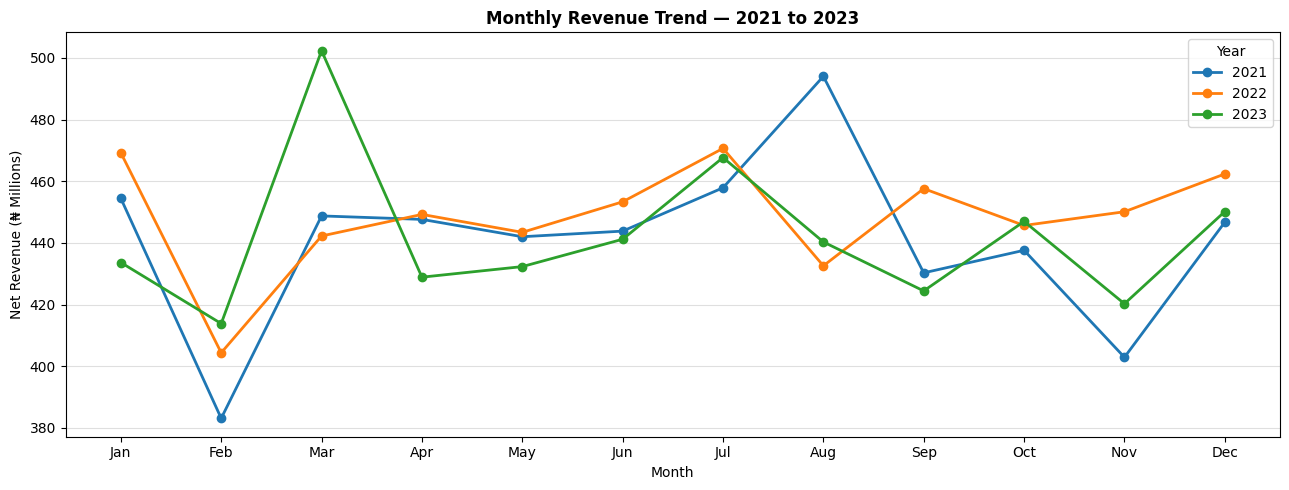

In [20]:
%matplotlib inline

# Group revenue by year and month
monthly = df.groupby(['year', 'month'])['net_revenue'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))

# Plot one line per year
for year, group in monthly.groupby('year'):
    ax.plot(group['month'], group['net_revenue'] / 1e6,
            marker='o', linewidth=2, label=str(year))

# Formatting
ax.set_title('Monthly Revenue Trend — 2021 to 2023', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Net Revenue (₦ Millions)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='Year')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

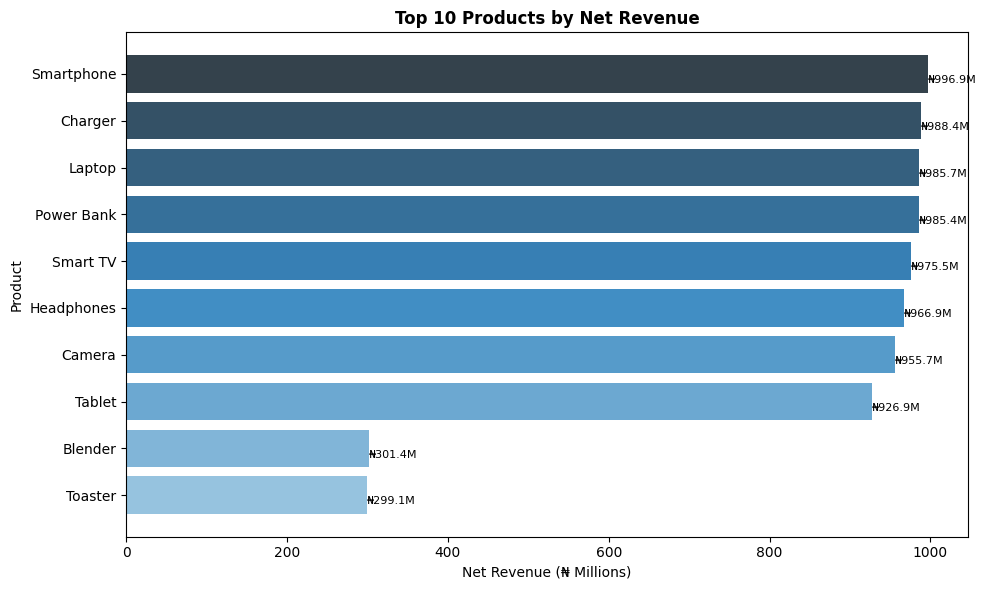

In [21]:
# 16. Create a bar chart showing top 10 products by total revenue

top10_products = (df.groupby('product_name')['net_revenue']
                  .sum()
                  .nlargest(10)
                  .reset_index()
                  .sort_values('net_revenue'))  # sort ascending for horizontal bar

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top10_products['product_name'], 
               top10_products['net_revenue'] / 1e6,
               color=sns.color_palette('Blues_d', 10))

# Add value labels on each bar
for bar, val in zip(bars, top10_products['net_revenue'] / 1e6):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 3,
            f'₦{val:.1f}M', va='center', fontsize=8)

ax.set_title('Top 10 Products by Net Revenue', fontweight='bold')
ax.set_xlabel('Net Revenue (₦ Millions)')
ax.set_ylabel('Product')
plt.tight_layout()
plt.show()

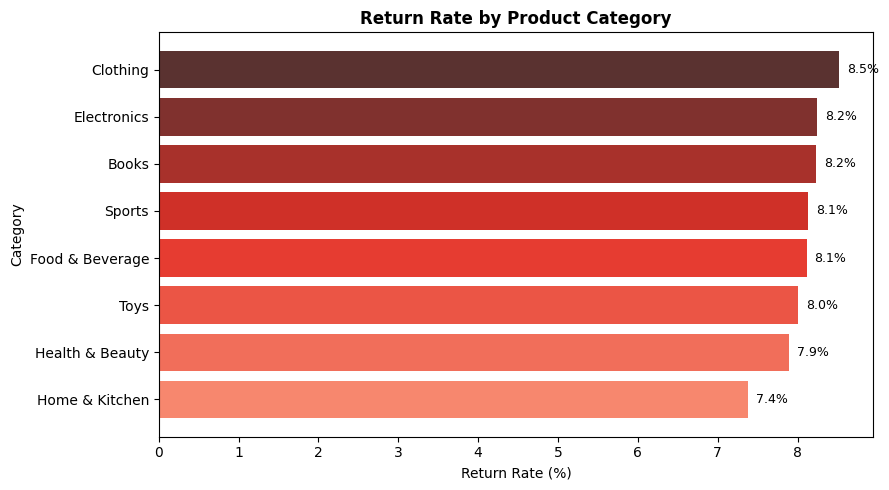

In [22]:
# 17.Visualize return rates by product category using a horizontal bar chart

# Calculate return rate per category
return_rate = (df.groupby('category')
               .agg(total_orders=('returned', 'count'),
                    returned_orders=('returned', lambda x: (x == 'Yes').sum()))
               .assign(return_rate=lambda r: r['returned_orders'] / r['total_orders'] * 100)
               .sort_values('return_rate'))

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(return_rate.index, return_rate['return_rate'],
               color=sns.color_palette('Reds_d', len(return_rate)))

# Add percentage labels
for bar, val in zip(bars, return_rate['return_rate']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_title('Return Rate by Product Category', fontweight='bold')
ax.set_xlabel('Return Rate (%)')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

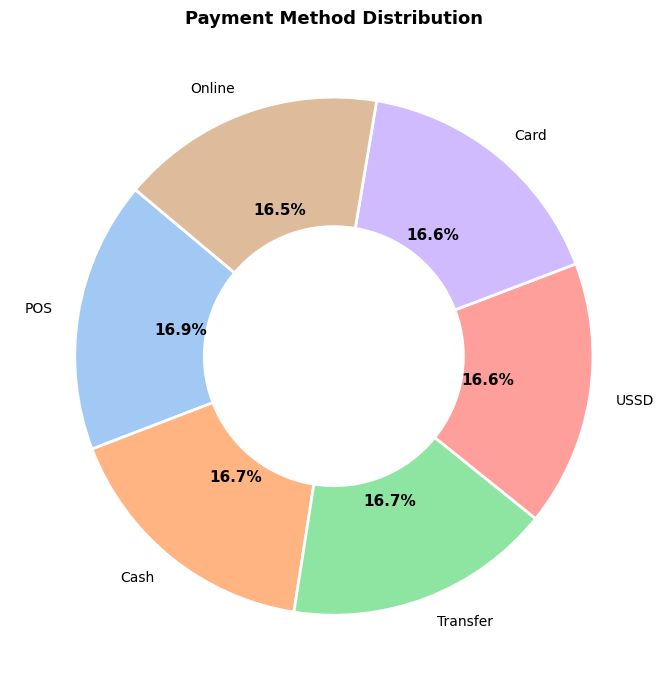

In [23]:
# 18.Analyse payment method distribution using a pie/donut chart

# Count transactions per payment method
payment_counts = df['payment_method'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel'),
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)  # width=0.5 makes it a donut
)

# Make percentage text bigger
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Payment Method Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

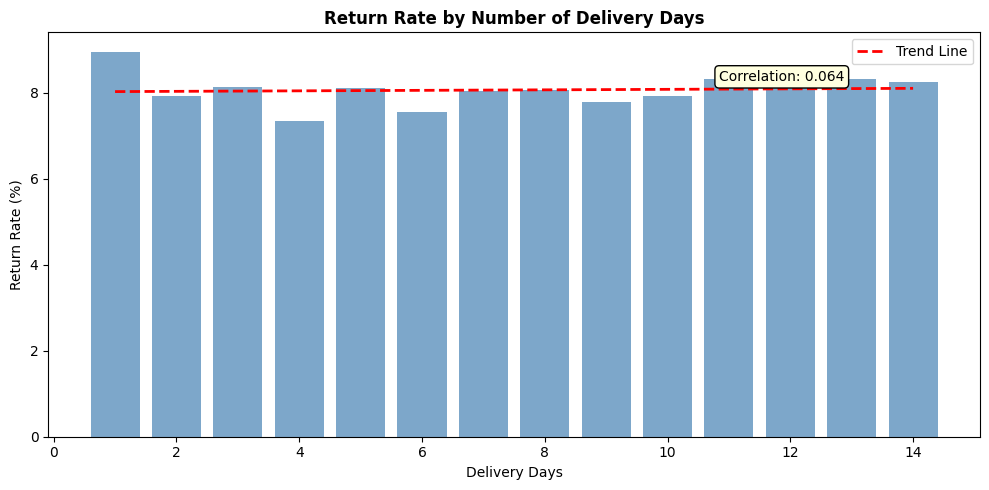

Correlation between delivery days and return rate: 0.064


In [24]:
# 19.Compute and visualize correlation between delivery_days and return rate

# Calculate return rate for each delivery day value
delivery_return = (df.groupby('delivery_days')
                   .agg(total=('returned', 'count'),
                        returned=('returned', lambda x: (x == 'Yes').sum()))
                   .assign(return_rate=lambda r: r['returned'] / r['total'] * 100)
                   .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))

# Bar chart
ax.bar(delivery_return['delivery_days'], delivery_return['return_rate'],
       color='steelblue', alpha=0.7)

# Add trend line
z = np.polyfit(delivery_return['delivery_days'], delivery_return['return_rate'], 1)
p = np.poly1d(z)
ax.plot(delivery_return['delivery_days'], p(delivery_return['delivery_days']),
        'r--', linewidth=2, label='Trend Line')

# Compute correlation
corr = delivery_return['delivery_days'].corr(delivery_return['return_rate'])
ax.text(0.72, 0.88, f'Correlation: {corr:.3f}', transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))

ax.set_title('Return Rate by Number of Delivery Days', fontweight='bold')
ax.set_xlabel('Delivery Days')
ax.set_ylabel('Return Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Correlation between delivery days and return rate: {corr:.3f}")

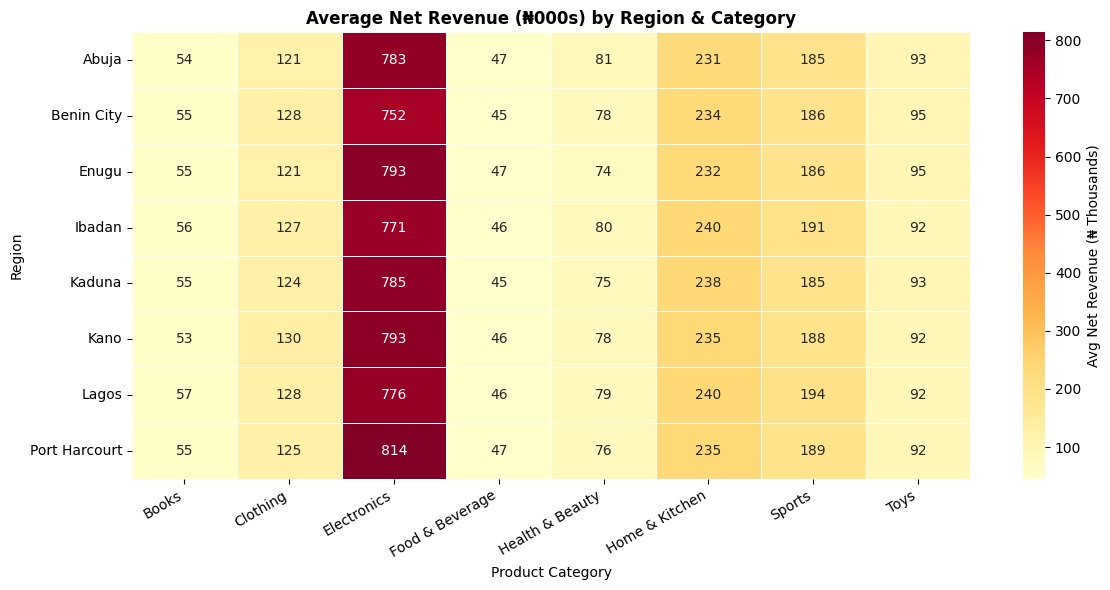

In [25]:
# 20.Build a heatmap showing average revenue by region and category


pivot = df.pivot_table(values='net_revenue', 
                       index='region', 
                       columns='category', 
                       aggfunc='mean')

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(pivot / 1e3, 
            annot=True, 
            fmt='.0f', 
            cmap='YlOrRd',
            linewidths=0.5, 
            ax=ax,
            cbar_kws={'label': 'Avg Net Revenue (₦ Thousands)'})

ax.set_title('Average Net Revenue (₦000s) by Region & Category', fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Region')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5 Key Findings — ShopEase Nigeria Retail Sales Analysis

**Finding 1 — Smartphones Drive the Most Revenue**
Smartphones ranked as the top product by net revenue across the entire dataset.
ShopEase should prioritize smartphone stock levels, promotions, and supplier relationships.

**Finding 2 — Clothing Has the Highest Return Rate**
The Clothing category recorded the highest return rate among all product categories.
This is likely due to sizing or quality mismatches. Better product descriptions,
size guides, and quality checks are recommended.

**Finding 3 — Delivery Time Does Not Drive Returns**
The correlation between delivery days and return rate was only 0.064 — extremely weak.
This means logistics speed is not the primary cause of returns. Focus should shift
to product quality and accurate listings instead.

**Finding 4 — POS is the Dominant Payment Method**
POS transactions account for the largest share of payments at ShopEase.
Any disruption to POS infrastructure could significantly impact sales.
Promoting alternative payment channels is advisable.

**Finding 5 — Port Harcourt Leads in Regional Revenue**
Port Harcourt consistently showed the highest average revenue across product categories.
Underperforming regions should be studied against Port Harcourt's model to identify
gaps in marketing, staffing, or product availability.